# Routing

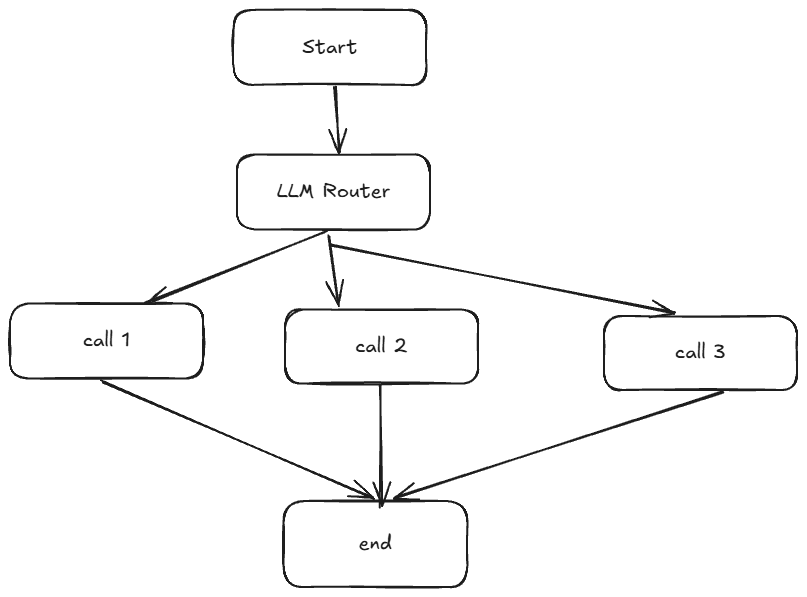

In [1]:
# import your LLM model
from langchain_ollama import ChatOllama
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image,display,Markdown
from typing_extensions import Literal
from pydantic import BaseModel,Field
from langchain_core.messages import HumanMessage,SystemMessage
llm = ChatOllama(model='llama3.1:8b')
results = llm.invoke('Hello my name is Hanif')
print(results)

content='Nice to meet you, Hanif! Is there something I can help you with or would you like to chat?' additional_kwargs={} response_metadata={'model': 'llama3.1:8b', 'created_at': '2025-11-29T14:06:19.6025669Z', 'done': True, 'done_reason': 'stop', 'total_duration': 8102656600, 'load_duration': 5666150200, 'prompt_eval_count': 16, 'prompt_eval_duration': 719949600, 'eval_count': 24, 'eval_duration': 1715409500, 'model_name': 'llama3.1:8b'} id='run--1fdd10b2-58c0-4844-b0e3-6ed3d405e9b1-0' usage_metadata={'input_tokens': 16, 'output_tokens': 24, 'total_tokens': 40}


In [2]:
# Schema for structured output as routing logic
class Route(BaseModel):
    step: Literal["poem","story","joke"]=Field(description="The next step in routing process")

# Augment theLLM with schema for structured output
router = llm.with_structured_output(Route)

## State(TypedDict)
class State(TypedDict):
    input:str
    decision:str
    output:str

def llm_call_1(state:State):
    """write a story"""
    result = llm.invoke(state['input'])
    return {"output":result.content}

def llm_call_2(state:State):
    """write a poem"""
    result = llm.invoke(state['input'])
    return {"output":result.content}

def llm_call_3(state:State):
    """write a joke"""
    result = llm.invoke(state['input'])
    return {"output":result.content}

def llm_call_router(state:State):
    """Route the input to the appropriate node"""
    decision = router.invoke(
        [
            SystemMessage(content="Route the input to story,joke or poem based onusers request"),
            HumanMessage(content = state["input"])
        ]
    )
    return{"decision":decision.step}

def route_decision(state:State):
    if state['decision'] == 'story':
        return 'llm_call_1'
    elif state['decision'] == 'poem':
        return 'llm_call_2'
    elif state['decision'] == 'joke':
        return 'llm_call_3'

In [3]:
router_builder = StateGraph(State)
router_builder.add_node("llm_call_1",llm_call_1)
router_builder.add_node("llm_call_2",llm_call_2)
router_builder.add_node("llm_call_3",llm_call_3)
router_builder.add_node("llm_call_router",llm_call_router)

router_builder.add_edge(START,"llm_call_router")
router_builder.add_conditional_edges(
    "llm_call_router",
    route_decision,
    {
        "llm_call_1":"llm_call_1",
        "llm_call_2":"llm_call_2",
        "llm_call_3":"llm_call_3"
    }
)
router_builder.add_edge("llm_call_1",END)
router_builder.add_edge("llm_call_2",END)
router_builder.add_edge("llm_call_3",END)

router_workflow = router_builder.compile()


In [4]:
mermaid_code = router_workflow.get_graph().draw_mermaid()
with open("router_workflow.mmd", "w") as f:
    f.write(mermaid_code)

In [5]:
result = router_workflow.invoke({"input":"Write me a joke about Data Engineer"})

In [6]:
# Stream to monitoring graph execution
config = {'configurable': {'thread_id': '3'}}
state={"input":"Give me a story about Government"}
for chunk in router_workflow.stream(state,config,stream_mode='updates'):
    print(chunk)

{'llm_call_router': {'decision': 'story'}}
{'llm_call_1': {'output': 'Here\'s a story about the inner workings of government:\n\nIt was a typical Monday morning at City Hall, with bureaucrats rushing to and fro, sipping their coffee and checking their emails. But amidst all the chaos, a small group of officials were gathered in the conference room, trying to navigate a particularly knotty issue.\n\nThe city\'s mayor, Rachel Lee, sat at the head of the table, flanked by her chief of staff, Mark Thompson, and a handful of department heads. They were discussing a contentious proposal to build a new high-rise development on the waterfront, which had been years in the making but was now facing fierce opposition from local residents.\n\nRachel leaned forward, her voice firm but measured. "I know we\'ve had some pushback from the community, but I truly believe this project is a game-changer for our city. It will bring in new revenue, create jobs, and help revitalize our downtown area."\n\nMar